# 分類 (classification)
### MNIST data: hand-written characters of digits
### 手書き数字認識
NIST: National Institute of Standards and Technology, US
アメリカ国立標準技術研究所

MNIST: Modified National Institute of Standards and Technology database

## Deep neural network, or deep learning
### Frameworks for neural networks
### ディープニューラルネットワーク用フレームワーク
- TensorFlow (Google, California) + Keras
- Torch, PyTorch (Facebook, California)
- Chainer (Preferred Networks, Tokyo)
- Caffe (Yangqing Jia, UCBerkeley)
- Theano (Bengio, et al., Canada)

等があるが，今回はディープラーニングは使わない．

## Scikit-Learn

Python の機械学習の総合ライブラリで，ディープラーニング以外は全て実装されている．今回は，これを使う．
（Deep ではない機械学習を shallow な機械学習と呼ぶ研究者もいる）

```python
from sklearn import datasets, metrics
#from keras.datasets import mnist
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
 # データはインターネットから取ってきて，
 # 訓練(学習)用の入力(x)・出力(y)，テスト用の入力(x)・出力(y) に代入
#(x_train, y_train), (x_test, y_test) = mnist.load_data()
X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
```

In [14]:
from sklearn import datasets, metrics
# from keras.datasets import mnist
from sklearn.datasets import fetch_openml
import numpy as np
import matplotlib.pyplot as plt
 # データはインターネットから取ってきて，
 # 訓練(学習)用の入力(x)・出力(y)，テスト用の入力(x)・出力(y) に代入
# (x_train, y_train), (x_test, y_test) = mnist.load_data()
x, y = fetch_openml('mnist_784', version=1, return_X_y=True)

In [15]:
x

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
y

,class
0,5
1,0
2,4
3,1
4,9
...,...
69995,2
69996,3
69997,4
69998,5


Scikit Learn で読み込む MNIST 手書き数字データは，784次元の画像データ（28×28ピクセル）が，70000個入っている．

本来 MNIST データは，
*   最初の60000個が訓練データ
*   残りの10000個がテストデータ

検証データは当時はなかった．

またこの形は，Pandas パッケージのデータフレーム（統計ソフト R で用いられるデータ形式で，表形式データ）なので，Scikit-Learn は NumPy の配列 (n-dimenstional array = ndarray) を使うので，変換する．

データフレームの「values」属性（プロパティ）を使うことで取り出せる．
（教科書 p.324 ）

（教科書では，データ行列を大文字 X で表すが，ここでは小文字 x で進める）

In [17]:
x = x.values         # オブジェクト x に，x.values とすると，values 属性(プロパティ)を取り出せる
y = y.astype(int).values    # ラベルデータとして整数(int)型にしたいので，astype(int)で変換（しないと 1.00 のような浮動小数点型 (float) になる

1個目のデータは，
```python
x[0]
```
として取り出せる．

In [18]:
type(y)

numpy.ndarray

### データを見る (See the data)
matplotlib (plt) の imshow 関数で2次元配列を表示することができる  
cmap はカラーマップ (色付け)，指定なしの場合は黄色と青  
ここでｈ，gray(グレー) の r (白黒反転 reverse)
```python
plt.imshow(x[0], cmap='gray_r')
```
で1個目のデータを見てみる．

（imshow は，matplotlib.plot の2次元配列を画像 (image) として表示する機能）

ただしこのままでは，元の x[0] は1次元配列 (784次元) で表示できないので，numpy.ndarray である x[0] の reshape メソッド (総要素数を変えずに，1次元 784 を 2次元 28x28 に変換する)． (教科書 p.325)

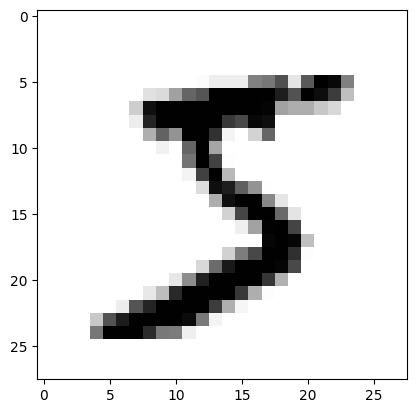

In [19]:

plt.imshow(x[0].reshape(28, 28),  cmap='gray_r')

## **課題1：150個目のデータを見る**

KUTLMS（課題1 第2回(6/12))から答える
https://lms.kochi-tech.ac.jp/mod/quiz/view.php?id=236237

### 教師出力（正解）を見る
Ground Truth (正解) と呼ぶ
```python
y[0]
```

In [20]:
y[0]

np.int64(5)

## データをまず訓練 (train) とテスト (test) に分ける
```python
x_train, x_test = x[0:60000], X[60000:70000]
y_train, y_test = y[0:60000], y[60000:70000]
```
[a:b] と書くのは，配列 ndarray の a 個目(「0」が1個目）から，b - 1 個目までを取り出す操作．最初と最後は，省略していいので，
```python
x_train, x_test = x[:60000], X[60000:]
y_train, y_test = y[:60000], y[60000:]
```
と書いても一緒．

ハイパーパラメータチューニングやモデル比較をする際は，更に，訓練データから検証データ (validation (val) ) を分けておく必要があるが，今日は valid は使わない（教科書 p.326）．

In [21]:
x_train, x_test = x[0:60000], x[60000:70000]
y_train, y_test = y[0:60000], y[60000:70000]

## 最初の5個のデータを for 文で表示
### See 5 data from the first
subplot を使うことで1つの図内に横に5つ並べて表示する  
subplot 関数の引数（縦の行数，横の列数，左上から数えて何番目の位置に書くか指定(1から数える)）  
下記の例は，1行5列に5個表示する．
```python
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.title(i)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
```

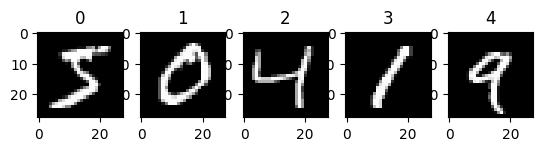

In [22]:
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.title(i)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')

# 課題2 : 15個のデータを3行5列で表示しなさい．

ヒント，range(5) と subplot の行を書き換えればできます．
subplot の行を，KUTLMS 課題2に書いてください．

In [10]:
15個のデータを3行5列で表示しなさい

SyntaxError: invalid syntax (1452017578.py, line 1)

### 計算時間短縮のため，データを60000個のうち最初の1000個だけを使う
Number of data is restricted to 1000 because of the computation cost
```python
data_size = 1000
x_train1 = x_train[0:data_size]
y_train1 = y_train[0:data_size]
x_test1 = x_test[0:data_size]
y_test1 = y_test[0:data_size]
```

In [36]:
x_train1 = x_train
y_train1 = y_train
x_test1 = x_test
y_test1 = y_test

# ここから，教科書3章に出てくる様々な分類器を使って，MNIST 分類（文字認識（パターン認識），予測）をする．

# 1. ロジスティック回帰 (Logistic regression)
### ライブラリを読み込む
load library

教科書 p.69 (3.3.4節)

```python
from sklearn.linear_model import LogisticRegression
```

In [37]:
from sklearn.linear_model import LogisticRegression

### 分類器を定義する
Define classifier
ここでは，ロジスティック回帰モデル（線形回帰モデルを分類に使うモデル）を clf_lr （分類器_ロジ回帰の略）として定義
```python
clf_lf = LogisticRegression()
```

In [38]:
clf_lf = LogisticRegression()

In [39]:
clf_lf

LogisticRegression()

### 学習を行う (訓練，fit とも言う)．
訓練データを使う
### Train (fit) the model using training data
```python
clf_lf.fit(x_train1, y_train1)
```

In [40]:
clf_lf.fit(x_train1, y_train1)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

### テストデータで性能を評価する
### Evaluate the model accuracy using test data
```python
clf_lf.score(x_test1, y_test1)
```

In [41]:
clf_lf.score(x_test1, y_test1)

0.9255

### まだ見たことのないテストデータを予測（predict, ここでは認識）してみる
array (配列) 形式で出力される．複数の入力をまとめて与えたら複数出力される．  
ここでは，1つの入力のみなので，1つの要素の配列が出力．  
配列の要素 [0] を最後に記述すれば，値を取り出せる．
### Predict unseen value using test input
```python
clf_lf.predict(x_test1[[0]])
```

In [42]:
clf_lf.predict(x_test1[[0]])

array([7])

In [43]:
clf_lf.predict_proba(x_test1[[0]]).reshape(10,) # 各クラスの確率が分かる

array([1.26599998e-06, 1.14589648e-13, 2.15117297e-06, 2.00501722e-03,
       7.00544474e-08, 4.19484877e-06, 7.85482420e-12, 9.97526696e-01,
       2.30630701e-05, 4.37541940e-04])

In [44]:
#各クラスの確率をグラフで見てみる

#classes = ['0','1','2','3','4','5','6','7','8','9']
#probabilities = clf_lf.predict_proba(x_test1[[0]]).reshape(10,)
#plt.bar(classes, probabilities, color=['orange'])


### x_test1 の1000個のテストデータを全て predict し，predicted に代入
### 正解データ y_test1 を expected (期待される出力) に代入
### predict value y' and true value (expected value) y
```python
predicted = clf_lf.predict(x_test1)
expected = y_test1
```

In [45]:
predicted = clf_lf.predict(x_test1)
expected = y_test1

### 正解 expected と 予測結果 predicted を使って精度を評価
答え合わせをする
### See the detail evaluation
```
print(metrics.classification_report(expected, predicted))
```

In [46]:
print(metrics.classification_report(expected, predicted))

              precision    recall  f1-score   support

           0       0.95      0.98      0.97       980
           1       0.97      0.98      0.97      1135
           2       0.93      0.90      0.91      1032
           3       0.90      0.91      0.91      1010
           4       0.93      0.93      0.93       982
           5       0.90      0.87      0.89       892
           6       0.94      0.95      0.95       958
           7       0.93      0.93      0.93      1028
           8       0.87      0.89      0.88       974
           9       0.91      0.91      0.91      1009

    accuracy                           0.93     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.93      0.93      0.93     10000



| Index | 指標 | 意味 |
| ---- | ---- | ---- |
| Precision | **適合率** |  0 と予測した物のうち正解だった物|
| Recall | **再現率** | 本来 0 である物のうち，いくつ 0 と予測できたか|
| F1-score | **F1スコア** | 適合率と再現率の調和平均，F値，Fスコアとも|
| Support | **台集合，サポート** | 正解データ数|
| Accuracy | **正答率，正解率** | 予測全体のうちの正解予測数|



# **混同行列を表示し検討する**
### See the confusion matrix for detail
```
print(metrics.confusion_matrix(expected, predicted))
```

In [47]:
print(metrics.confusion_matrix(expected, predicted))

[[ 963    0    0    3    1    3    4    4    2    0]
 [   0 1112    4    2    0    1    3    2   11    0]
 [   3   10  926   15    6    4   15    8   42    3]
 [   4    1   21  916    1   26    3    9   22    7]
 [   1    1    7    3  910    0    9    7   10   34]
 [  11    2    1   33   11  776   11    6   35    6]
 [   9    3    7    3    7   16  910    2    1    0]
 [   1    6   24    5    7    1    0  951    3   30]
 [   8    7    6   23    6   26   10   10  869    9]
 [   9    7    0   11   25    6    0   22    7  922]]


## 混同行列の見方
縦の各行は，正解クラス「0」～「9」  
横の各列は，予測クラス「0」～「9」  

行列の各要素 ij (i行j列) の値は，正解 i のものを j と予測した個数．

### 混同行列を色付きで表示
### See the confusion matrix by graphical illustration

```python
import seaborn as sns
confmat = metrics.confusion_matrix(expected, predicted)
plt.figure(figsize=(16,16))
sns.heatmap(confmat, annot=True, fmt=".3f", square = True, cmap = 'Blues_r')
plt.ylabel('Expected Class')
plt.xlabel('Predicted label')
```

Text(0.5, 266.7222222222221, 'Predicted label')

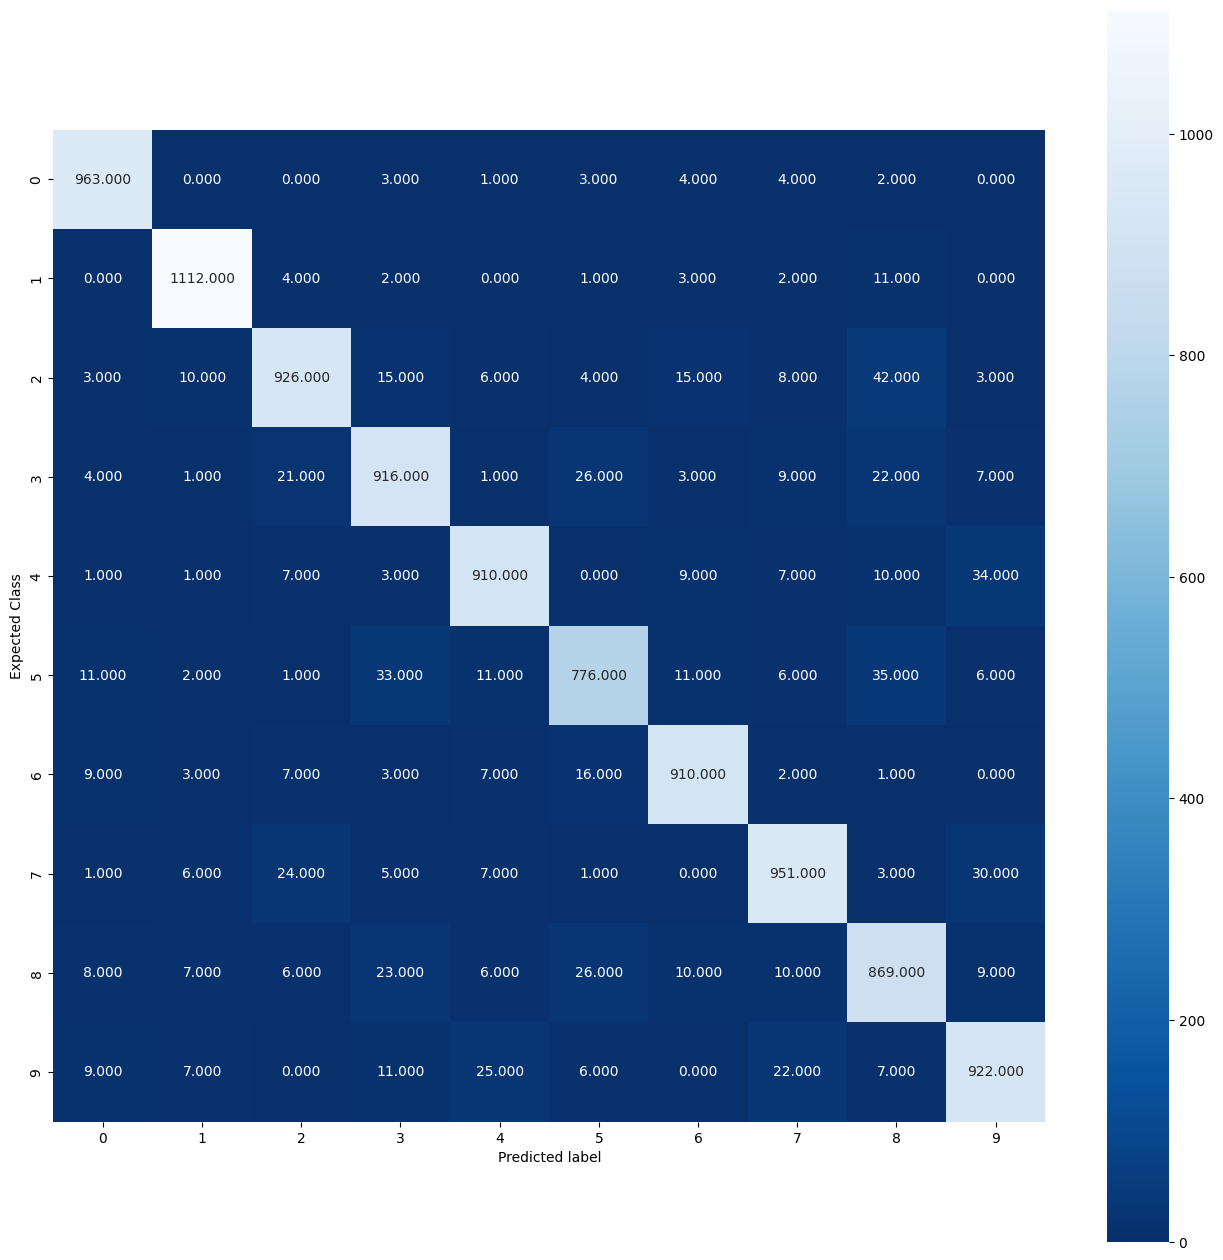

In [48]:
import seaborn as sns
confmat = metrics.confusion_matrix(expected, predicted)
plt.figure(figsize=(16,16))
sns.heatmap(confmat, annot=True, fmt=".3f", square = True, cmap = 'Blues_r')
plt.ylabel('Expected Class')
plt.xlabel('Predicted label')

## ロジスティック回帰の係数を見る
### See the coefficients
```
clf_lf.coef_
```

In [49]:
clf_lf.coef_

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

## ロジスティック回帰の切片を見る
###See the intercept of the line
```
clf_lf.intercept_
```

In [50]:
clf_lf.intercept_

array([-6.61940951e-05,  4.73003395e-05,  5.36508323e-05, -7.16796054e-05,
        9.66199834e-06,  3.51673863e-04, -2.41825055e-05,  1.13381682e-04,
       -3.43023074e-04, -7.05894354e-05])

## 誤認識したデータを確認する
### See incorrectly classified data
何番目のデータについて，本来正解の値と，予測した値
```python
i = 0
mis_idx = []
for exp, pred in zip(expected, predicted):
    if exp != pred:
        print(i, exp, pred)
        mis_idx.append(i)
    i = i + 1
```

In [51]:
i = 0
mis_idx = []
for exp, pred in zip(expected, predicted):
    if exp != pred:
        print(i, exp, pred)
        mis_idx.append(i)
    i = i + 1

8 5 6
33 4 6
63 3 2
66 6 3
124 7 4
149 2 9
193 9 3
195 3 8
211 5 7
217 6 5
233 8 7
241 9 8
245 3 5
247 4 2
259 6 0
300 4 6
307 7 9
320 9 7
321 2 7
340 5 3
344 8 5
352 5 0
359 9 4
362 2 7
381 3 7
391 8 5
435 8 7
444 2 8
445 6 0
448 9 8
469 5 8
478 5 8
479 9 3
502 5 3
507 3 5
511 4 8
516 2 6
528 3 2
531 3 6
536 2 1
543 8 3
551 7 1
565 4 9
569 3 4
578 3 2
582 8 1
583 2 8
591 8 3
613 2 8
619 1 8
629 2 6
659 2 8
684 7 2
691 8 4
692 5 7
707 4 9
717 0 6
720 5 8
728 2 8
740 4 9
741 2 8
760 4 9
791 5 9
829 4 8
839 8 3
844 8 7
857 5 3
874 9 4
877 8 2
881 4 9
882 9 7
890 3 5
898 7 2
938 3 5
939 2 0
947 8 9
950 7 2
951 5 4
956 1 2
965 6 0
975 2 3
999 9 7
1012 7 9
1014 6 5
1017 6 2
1028 3 5
1032 5 8
1033 8 3
1039 7 9
1044 6 2
1062 3 9
1082 5 3
1101 8 2
1107 9 3
1112 4 6
1114 3 8
1128 3 7
1181 6 1
1182 6 8
1191 0 7
1192 9 4
1194 7 9
1198 8 4
1204 3 9
1206 7 2
1208 3 9
1226 7 2
1232 9 4
1234 8 5
1242 4 9
1247 9 3
1252 5 3
1256 2 3
1260 7 1
1283 7 2
1289 5 9
1299 5 7
1310 3 7
1319 8 3
1325 8 6
1326 7 

## 全部でいくつ間違えているかを表示
### Number of incorrectly classified data
```python
len(mis_idx)
```

In [52]:
len(mis_idx)

745

## 間違えたデータの最初の50個を表示
### See the first 50 misclassified data
```python
plt.figure(figsize=(16,16))
for i, ng in enumerate(mis_idx[0:50]):
    plt.subplot(5, 10, i + 1)
    plt.imshow(x_test[ng], cmap='gray_r')
    plt.title('Pred: {}, Ans: {}'.format(predicted[ng], expected[ng]), fontsize = 8)
```

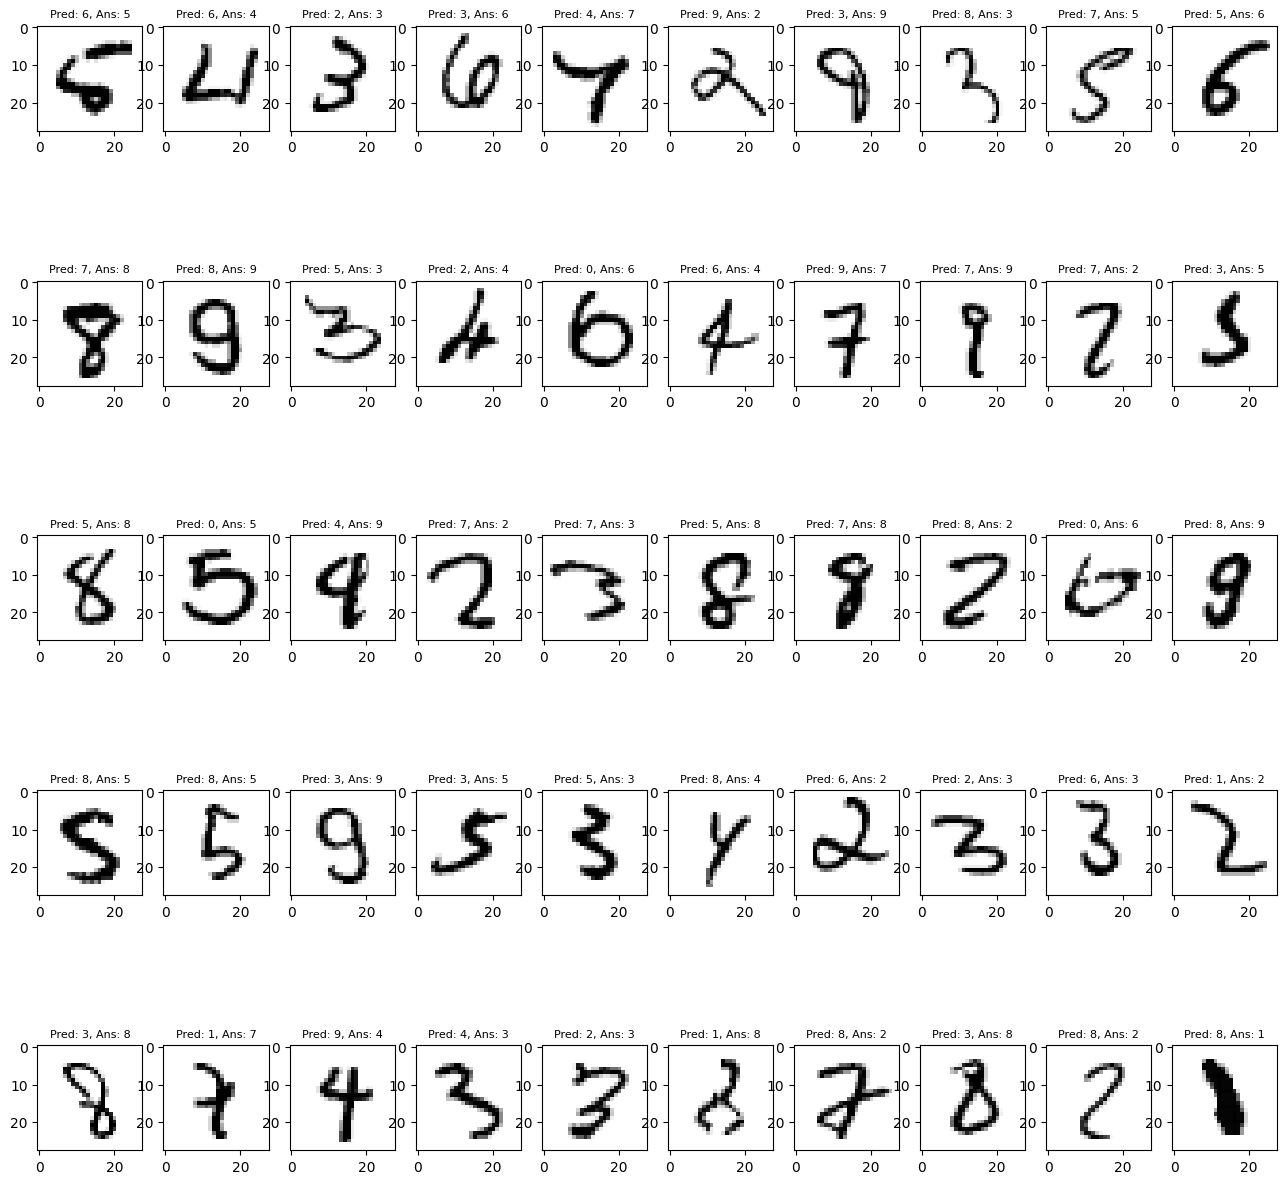

In [53]:
plt.figure(figsize=(16,16))
for i, ng in enumerate(mis_idx[0:50]):
    plt.subplot(5, 10, i + 1)
    plt.imshow(x_test[ng].reshape(28, 28), cmap='gray_r')
    plt.title('Pred: {}, Ans: {}'.format(predicted[ng], expected[ng]), fontsize = 8)

# 2. SVM : サポートベクトルマシン
support vector machine

非線形のモデルで，汎化性能が高い．

3.4.2 節 (p.77) の SVC （サポートベクトル分類器）を使う．

### Load library
```python
from sklearn.svm import SVC
```

In [54]:
from sklearn.svm import SVC

## 線形カーネル（＝カーネルトリックを使わない）モデルを作る
```python
clf_svml = SVC(kernel='linear')
```

In [55]:
clf_svml = SVC(kernel='linear')

### 訓練（Train = fit) する
```python
clf_svml.fit(x_train1, y_train1)
```

In [ ]:
clf_svml.fit(x_train1, y_train1)

```python
predicted_svml = clf_svml.predict(x_test1)
expected_svml = y_test1
```

In [ ]:
predicted_svml = clf_svml.predict(x_test1)
expected_svml = y_test1

```python
print(metrics.classification_report(expected_svml, predicted_svml))
```

In [ ]:
print(metrics.classification_report(expected_svml, predicted_svml))

In [ ]:
print(metrics.confusion_matrix(expected_svml, predicted_svml))



## 3. カーネルを変えたサポートベクトルマシン

RBF カーネル（3.5.2節 p.80-81，ガウスカーネルとも呼ぶ）や，多項式カーネル（2次関数，3次関数，etc. scikit-learn のマニュアル https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC 等も参考に）を使ったモデルを使う．

In [ ]:
clf_svmr = SVC(kernel='sigmoid')
clf_svmr.fit(x_train1, y_train1)
predicted_svmr = clf_svmr.predict(x_test1)
expected_svmr = y_test1
print(metrics.classification_report(expected_svmr, predicted_svmr))


# 4. パーセプトロン，Perceptron
- 最も簡素なニューラルネットワーク (Most simple neural network)
- マカロックピッツの形式ニューロン[1943]，ロゼンブラットの学習アルゴリズム[1958]
- ローゼンブラットの単層パーセプトロン
- 1960年代に線形モデルと等価であることが示された
- Mucolloch-Pitts, formal neuron model [1943], and the learning by Rosenblatt [1958].
- Rosenblatt's single layer perceptron
- In 1960s, equivalence to linear model is suggested.

### Load library
```python
from sklearn.linear_model import Perceptron
```

In [ ]:
from sklearn.linear_model import Perceptron

### Define Perceptron classifier as clf
```python
clf_p = Perceptron()
```

In [ ]:
clf_p = Perceptron()

### Train (fit) the model
```python
clf_p.fit(x_train1, y_train1)
```

In [ ]:
clf_p.fit(x_train1, y_train1)

### Evaluate the model
```python
clf_p.score(x_test1, y_test1)
```

In [ ]:
clf_p.score(x_test1, y_test1)

```python
predicted_nn = clf_p.predict(x_test1)
expected_nn = y_test1
```

In [ ]:
predicted_nn = clf_p.predict(x_test1)
expected_nn = y_test1

```python
print(metrics.classification_report(expected_nn, predicted_nn))
```

In [ ]:
print(metrics.classification_report(expected_nn, predicted_nn))

```python
print(metrics.confusion_matrix(expected_nn, predicted_nn))
```

In [ ]:
print(metrics.confusion_matrix(expected_nn, predicted_nn))

## 5. 多層パーセプトロン：MLP: multi-layered perceptron
- Rumelhart, Hinton, Williams (Nature, 1986)
- Sigmoid function
- $y = \dfrac{1}{1+\exp(-x)}$
- Same as logistic regression for 1 neuron

```python
from sklearn.neural_network import MLPClassifier
```

In [ ]:


from sklearn.neural_network import MLPClassifier





```
# コード例
```

```python
clf_mlp1 = MLPClassifier(hidden_layer_sizes=(),activation='identity')
```

In [ ]:
clf_mlp1 = MLPClassifier(hidden_layer_sizes=(),activation='identity')


```
clf_mlp1
```
とだけ打ってモデルをみてみる

In [ ]:
clf_mlp1

```python
clf_mlp1.fit(x_train1, y_train1)
```

In [ ]:
clf_mlp1.fit(x_train1, y_train1)

In [ ]:
clf_mlp1.score(x_test1, y_test1)

```
clf_mlp2 = MLPClassifier(hidden_layer_sizes=(2,2),activation='identity')
```

In [ ]:


clf_mlp2 = MLPClassifier(hidden_layer_sizes=(1),activation='identity')



In [ ]:
clf_mlp2.fit(x_train1, y_train1)



In [ ]:
print( clf_mlp2.score(x_train1, y_train1) )
print( clf_mlp2.score(x_test1, y_test1) )


# **実際に手書き数字を認識させる**

### 1つ目のコードは画像 img の重心を返す関数を定義 centerOfMass(img)

In [ ]:
def centerOfMass(img):
  """
  画像imgの重心位置を返す
  :param PIL.Image.Image img: グレイスケール画像
  :rtype:  (int, int)
  :return: (重心のX座標, 重心のY座標)
  """
  import numpy as np

  m = np.asarray(img)	# NumPy配列に変換
  ht, wd = m.shape
  sum = np.sum(m)

  # https://stackoverflow.com/questions/37519238
  dx = np.sum(m, axis=0)	# 各列の合計からなるベクトル
  dy = np.sum(m, axis=1)	# 各行の合計からなるベクトル

  # np.arange(wd) == [0, 1, 2, ..., wd-1]
  cx = np.sum(dx * np.arange(wd)) / sum
  cy = np.sum(dy * np.arange(ht)) / sum

  return (int(np.rint(cx)), int(np.rint(cy)))

### 2つ目のコードは，IPython の機能を使い，ブラウザにHTMLとJavaScriptを表示・実行
### ここでは，HTML の canvas タグで，手書き用キャンバスを作る
200×200ピクセルで，「数字保存！」のボタンを押すと，書いた画像データを変数 img に格納して終了

In [ ]:
from IPython.display import HTML, Image
from google.colab.output import eval_js
from base64 import b64decode
from io import BytesIO
from PIL import Image

canvas_html = """
<canvas width=%d height=%d></canvas>
<button>数字保存！</button>
<script>
var canvas = document.querySelector('canvas')
var ctx = canvas.getContext('2d')
canvas.style.border = "2px solid"
ctx.lineWidth = %d
var button = document.querySelector('button')
var mouse = {x: 0, y: 0}
canvas.addEventListener('mousemove', function(e) {
  mouse.x = e.pageX - this.offsetLeft
  mouse.y = e.pageY - this.offsetTop
})
canvas.onmousedown = ()=>{
  ctx.beginPath()
  ctx.moveTo(mouse.x, mouse.y)
  canvas.addEventListener('mousemove', onPaint)
}
canvas.onmouseup = ()=>{
  canvas.removeEventListener('mousemove', onPaint)
}
var onPaint = ()=>{
  ctx.lineTo(mouse.x, mouse.y)
  ctx.stroke()
}
var data = new Promise(resolve=>{
  button.onclick = ()=>{
    resolve(canvas.toDataURL('image/png'))
  }
})
</script>
"""

# 200×200画素で，8画素の枠を付けてキャンバス表示
display(HTML(canvas_html % (200, 200, 8)))
data = eval_js("data")
# ボタンが押された後，canvasデータがbinaryに入る (BASE64エンコードで来るのでデコード)
binary = b64decode(data.split(',')[1])
img = Image.open(BytesIO(binary))

# 背景が透明なため，白背景画像 background を作り書いた文字を重ね，img に入れる
background = Image.new("RGB", img.size, (255, 255, 255))
background.paste(img, img)
img = background


### 画像の前処理を行う．
書いた画像 img に下記処理を行う．
- 余白部分を刈り取り(crop)
- 20×20の大きさにリサイズ
- 重心を中心に合わせる（文字を真ん中に持ってくる）
- MNIST の 28×28 の枠の中心に入れる
- Scikit Learn で使えるよう，

In [ ]:
from PIL import Image, ImageOps
img = img.convert('L')	# grayscale
display(img)
img = ImageOps.invert(img)	# negate
display(img)
img = img.crop(box=img.getbbox())	# crop
display(img)
wd, ht = img.size
# アスペクト比を変えずに20x20の矩形に収める
if wd < ht:
  wd = wd * 20 // ht
  ht = 20
else:
  ht = ht * 20 // wd
  wd = 20
#img = img.resize((wd, ht), Image.Resampling.LANCZOS)
img = img.resize((wd, ht))
display(img)
cx, cy = centerOfMass(img)	# 重心

# 重心を中心にして28x28の矩形の中に配置
bgImg = Image.new(img.mode, (28, 28), color=0)
ox = -cx + 28 // 2
oy = -cy + 28 // 2
bgImg.paste(img, (ox, oy))
img = bgImg
display(img)

## ここまでの関数 drawdigit() にまとめておく
関数の返り値 (return) は，28×28 の画像をさらに，NumPy の ndarray にし，1×784 の1次元配列に変換（Flatten）したものを返す．  
これで，そのまま，clf.predict に渡して認識（予測）できる．

In [ ]:
def drawdigit():
  canvas_html = """
  <canvas width=%d height=%d></canvas>
  <button>数字保存！</button>
  <script>
  var canvas = document.querySelector('canvas')
  var ctx = canvas.getContext('2d')
  canvas.style.border = "2px solid"
  ctx.lineWidth = %d
  var button = document.querySelector('button')
  var mouse = {x: 0, y: 0}
  canvas.addEventListener('mousemove', function(e) {
    mouse.x = e.pageX - this.offsetLeft
    mouse.y = e.pageY - this.offsetTop
  })
  canvas.onmousedown = ()=>{
    ctx.beginPath()
    ctx.moveTo(mouse.x, mouse.y)
    canvas.addEventListener('mousemove', onPaint)
  }
  canvas.onmouseup = ()=>{
    canvas.removeEventListener('mousemove', onPaint)
  }
  var onPaint = ()=>{
    ctx.lineTo(mouse.x, mouse.y)
    ctx.stroke()
  }
  var data = new Promise(resolve=>{
    button.onclick = ()=>{
      resolve(canvas.toDataURL('image/png'))
    }
  })
  </script>
  """

  display(HTML(canvas_html % (200, 200, 8)))
  data = eval_js("data")
  binary = b64decode(data.split(',')[1])
  img = Image.open(BytesIO(binary))

  background = Image.new("RGB", img.size, (255, 255, 255))
  background.paste(img, img)
  img = background

  img = img.convert('L')	# grayscale
  img = ImageOps.invert(img)	# negate
  img = img.crop(box=img.getbbox())	# crop
  wd, ht = img.size
  # アスペクト比を変えずに20x20の矩形に収める
  if wd < ht:
    wd = wd * 20 // ht
    ht = 20
  else:
    ht = ht * 20 // wd
    wd = 20
  #img = img.resize((wd, ht), Image.Resampling.LANCZOS)
  img = img.resize((wd, ht))
  cx, cy = centerOfMass(img)	# 重心

  # 重心を中心にして28x28の矩形の中に配置
  bgImg = Image.new(img.mode, (28, 28), color=0)
  ox = -cx + 28 // 2
  oy = -cy + 28 // 2
  bgImg.paste(img, (ox, oy))
  img = bgImg
  display(img)
  return np.asarray(img).astype(np.float32).reshape(1, 784)


## drawdigit() を実行し数字を手書きする．
```python
suuji = drawdigit()
```

In [ ]:
suuji = drawdigit()

## clf_***.predict に suuji を入れて認識させる
```python
print( clf_***.predict(suuji) )
```
または
```python
print( clf_***.predict(suuji)[0] )
```
[0] は配列の1つ目の値だけを取る操作

# 宿題1. 課外時間に下記を実行して報告してください．

### a. モデルは，は線形ロジスティック回帰モデル
### b. データは訓練用データ 60000 個，テスト用データ 10000個全て使う
### c. 評価は，適合率，再現率，F1スコア，正答率，混同行列を示す

# 宿題2. Scikit-Learnの他のモデル，ハイパーパラメータを試し，全データを作った訓練で，どこまで精度高められるか試す．

例えば，
### a1. 線形ロジスティック回帰の場合は，正則化 elastic-net を使って，L1_ratio や, alpha を変更

### a2. SVM の場合は，カーネルの種類，C や gamma 等のパラメータ値

### a3. 多層パーセプトロンの場合は隠れ層の数と，ニューロン数の変更

等．
### b. 下記サイトを参考に他のアルゴリズム（授業で用いなかったものも可）を試し精度向上を検討しなさい．


https://scikit-learn.org/stable/supervised_learning.html  


